In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

%load_ext autoreload
%autoreload 2
%matplotlib inline

Resolving data files: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1585/1585 [00:00<00:00, 654843.56it/s]


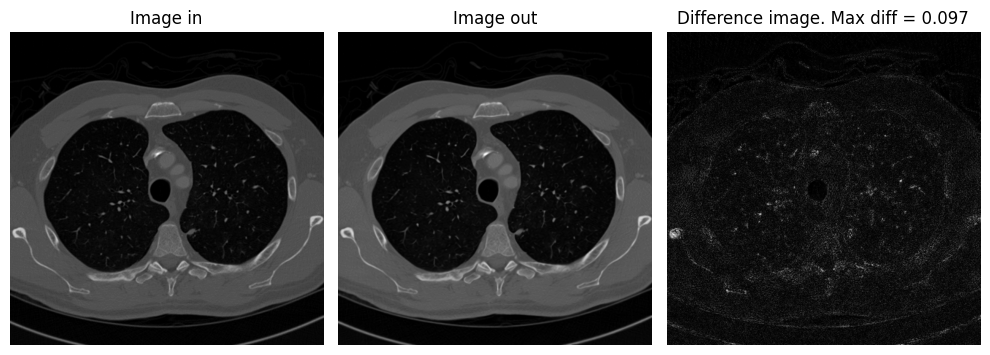

oks


In [ ]:
from diffusers import AutoencoderKL, VQModel
from datasets import load_dataset
from torchvision import transforms

vae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae")
vae.requires_grad_(False)
vae_scale_factor = 2 ** (len(vae.config.block_out_channels) - 1)
vae.cuda()

dataset_name="data/train_data/nodules_6mm_512x512"
dataset = load_dataset(dataset_name, split="train")
resolution = 512

augmentations = transforms.Compose(
    [
        transforms.CenterCrop((512, 512)),
        transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

sample_idx = 567
image_in = augmentations(dataset[sample_idx]["image"]).unsqueeze(0).cuda()

# encode
latents = vae.encode(image_in).latents
latents = latents * 0.18215
# decode
latents = latents / 0.18215
image_out = vae.decode(latents, return_dict=False)[0]


# convert tensors back to images
image_in = (image_in / 2 + 0.5).clamp(0, 1)
image_out = (image_out / 2 + 0.5).clamp(0, 1)
im_in = image_in.cpu().permute(0, 2, 3, 1).squeeze().float().numpy()
im_out = image_out.cpu().permute(0, 2, 3, 1).squeeze().float().numpy()
im_in = np.sum(im_in, axis=2)/3
im_out = np.sum(im_out, axis=2)/3

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Plot the first image on the left
axes[0].imshow(im_in, cmap='gray')
axes[0].set_title("Image in")
axes[0].axis('off')  # Turn off the axis

# Plot the second image on the right
axes[1].imshow(im_out, cmap='gray')
axes[1].set_title("Image out")
axes[1].axis('off')  # Turn off the axis

# Plot the difference
diff = abs(im_out - im_in)
#diff = (diff - diff.min())/(diff.max() - diff.min())
axes[2].imshow(diff, cmap='gray')
axes[2].set_title(f"Difference image. Max diff = {diff.max():.3f}")
axes[2].axis('off')  # Turn off the axis

# Show the plot
plt.tight_layout()
plt.show()